In [1]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import joblib
from sklearn.pipeline import Pipeline
import seaborn as sns
from src.selection_visualization import plot_lasso_vs_et

from src.split_visualization import plot_dst_split_distribution

from src.estimators import NaivePersistence, DirectARBaseline, XGBoostDst, LightGBMDst
from src.evaluate         import compute_metrics
from src.runner           import fit_model, log_metrics_run, print_horizon_metrics, run_segment
from src.mlflow_tracking  import setup_mlflow

# Cosmic Ray Storm Prediction — Feature Engineering

The exploratory analysis in `cosmic_ray_storm_prediction_EDA.ipynb` established the physical motivation and statistical properties of the datasets. The present notebook implements the Feature Engineering stage of the machine learning workflow.

## Introduction

Feature Engineering constructs the supervised learning dataset required by the forecasting task. Starting from the raw OMNI solar wind and LMKS neutron monitor measurements, this notebook produces the feature matrix used consistently throughout all subsequent modelling experiments.

The stage consists of the following steps:

- **Target Variable** — generates the h-hour-ahead $D_{st}$ targets for $h \in \{1, 3, 7, 12, 21\}$.
- **Derived Features** — constructs physically motivated features from the raw measurements.
- **Lag Features** — adds temporal history to the predictor set.
- **Cyclical Encoding** — encodes the solar cycle phase as continuous predictors.
- **Experimental Design** — defines the chronological train/validation/test split and saves all artifacts for downstream notebooks.

## Feature Engineering

This stage addresses the **forecasting task** defined in the Problem Formulation by transforming the consolidated `analysis_data` into a supervised learning dataset suitable for multi-horizon forecasting. The objective is to construct physically meaningful predictors and forecasting targets while preserving the temporal structure required for unbiased model training and evaluation.

Following the CME → solar wind → magnetosphere causal chain, lag horizons are determined by physical constraints—the Burton ring-current decay time `[BUR75]` and the Forbush Decrease precursor interval `[KIS25]`—ensuring that the predictor space remains physically interpretable rather than purely data-driven.

Two types of information leakage are explicitly prevented. Temporal look-ahead leakage is avoided by constructing all lag features exclusively from past observations (`shift(h)`, `h>0`) and by avoiding centred interpolation. Distribution leakage is prevented by estimating all preprocessing parameters exclusively from the training partition before applying them unchanged to the validation and test sets.

In [2]:
# ── Checkpoint — reload analysis_data ──────────────────────────────────────────
# Allows restarting the kernel and running from this cell during Feature
# Engineering / Modeling development, without re-running IDA / EDA.
# If analysis_data is already in memory (e.g. after Run All), it is reused as-is.

if os.path.exists('data/processed/analysis_data.parquet'):
   analysis_data = pd.read_parquet('data/processed/analysis_data.parquet')
   print(f"Checkpoint loaded: {len(analysis_data):,} rows")
else:
   raise RuntimeError("No checkpoint found — run the IDA / Data Preparation cells above first.")

Checkpoint loaded: 364,728 rows


### Target Variable

Target variables are generated immediately after construction of the cleaned feature table and before any temporal split or model training.

The regression target is the $D_{st}$ index shifted $N$ hours into the future:

$$\text{dst\_target}_t = D_{st}(t + N)$$

implemented as `feat['dst'].shift(-N)`. A negative shift places the future value at the current row — at fitting time the model sees only present and past inputs. Five regression targets are constructed for $N \in \{1, 3, 7, 12, 21\}$ hours.

**Leakage note.** The shifted target columns are excluded from the feature matrix before any fitting step. The raw `dst` column is retained as a direct predictor representing the currently observed value, but no shifted target is ever used as an input feature.

In [3]:
# ── Target Variable ──────────────────────────────────────────────────────
feat = analysis_data.copy()

# ── Constants ─────────────────────────────────────────────────────────────────
STORM_THR  = -50                   # nT — moderate-storm threshold (for reference only)
K_HORIZONS = [1, 3, 7, 12, 21]    # forecast horizons: Burton τ≈7-8h, Forbush lead 7-21h


def build_target(df, k):
    """
    Adds regression target for horizon k.

    Parameters
    ----------
    df : DataFrame with a 'dst' column
    k  : int — forecast horizon in hours
    """
    df[f"dst_target_{k}h"] = df["dst"].shift(-k)


print(f"Storm reference   : dst < {STORM_THR} nT")
print(f"Forecast horizons : {K_HORIZONS} h\n")
print(f"{'Horizon':>10} {'NaN':>6} {'Target min':>12} {'Target max':>12}")
print("-" * 44)
for k in K_HORIZONS:
    build_target(feat, k)
    col   = f"dst_target_{k}h"
    n_nan = feat[col].isna().sum()
    print(f"{k:>8}h  {n_nan:>6} {feat[col].min():>12.1f} {feat[col].max():>12.1f}")

Storm reference   : dst < -50 nT
Forecast horizons : [1, 3, 7, 12, 21] h

   Horizon    NaN   Target min   Target max
--------------------------------------------
       1h       1       -589.0         81.0
       3h       3       -589.0         81.0
       7h       7       -589.0         81.0
      12h      12       -589.0         81.0
      21h      21       -589.0         81.0


> **Observations — Target Variable:**
> - Five regression target columns (`dst_target_{1,3,7,12,21}h`) were generated, corresponding to the predefined forecasting horizons.
> - The number of missing values introduced by `shift(-k)` equals the forecast horizon (1, 3, 7, 12 and 21 samples respectively), confirming the expected target alignment.
> - All target columns preserve the original $D_{st}$ range (−589 to 81 nT), indicating that shifting changes only the temporal alignment and not the underlying value distribution.
> - The terminal rows containing undefined future targets are removed during the subsequent preprocessing stage before model fitting.

### Derived Features

Derived features are constructed from the original measurements to capture changes over time and relationships that are not directly visible in the raw data. All features use only information available at or before the forecast time.

| Feature | Transformation | Purpose |
|---|---|---|
| `d_neutron` | Relative first difference | Relative neutron flux change |
| `bz_acc_3h` | Rolling sum (3h) | Short-term southward IMF persistence |
| `bz_acc_6h` | Rolling sum (6h) | Medium-term southward IMF persistence |
| `bz_acc_12h` | Rolling sum (12h) | Long-term southward IMF persistence |
| `dbz_dt` | First difference | Hourly IMF change rate |

> **Note.** The OMNI dataset already includes the interplanetary electric field (`e_field`). Since this quantity is provided directly, no additional interaction feature is constructed.

#### Differential neutron flux (`d_neutron`)

The raw neutron count changes slowly over time. This feature measures the relative hourly change instead, making sudden decreases easier for the model to detect:

$$\delta n_t = \frac{N_t - N_{t-1}}{N_{t-1}}$$

The feature `d_neutron` is the implementation of the differential neutron flux $\delta n(t)$ introduced in the Problem Formulation. Here, the differencing window is fixed to $w = 1$ hour. The differencing window defines how the neutron signal is transformed and is independent of the forecasting horizon.

#### Accumulated southward $B_z$ (`bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h`)

A single negative value of $B_z$ is usually not enough to produce a storm. These rolling sums measure how long southward $B_z$ conditions persist:

$$\text{bz\_acc}_{w,t} = \sum_{k=0}^{w-1} B_{z,\,t-k}$$

#### IMF rotation rate (`dbz_dt`)

While the accumulated $B_z$ features measure persistence, `dbz_dt` measures how quickly the magnetic field changes from one hour to the next:

$$dbz\_dt_t = B_{z,t} - B_{z,t-1}$$

In [4]:
# ── Derived Features ─────────────────────────────────────────────────────

# Differential neutron flux
feat["d_neutron"] = (
    feat["neutron_counts"].diff() / feat["neutron_counts"].shift(1)
)

# Accumulated southward Bz
bz_south = feat["bz_gsm"].clip(upper=0)

for window in [3, 6, 12]:
    feat[f"bz_acc_{window}h"] = bz_south.rolling(window).sum()

# IMF rotation rate
feat["dbz_dt"] = feat["bz_gsm"].diff()

derived_cols = ["d_neutron", "bz_acc_3h", "bz_acc_6h", "bz_acc_12h", "dbz_dt"]

print(f"{'Feature':>15} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 65)
for col in derived_cols:
    s = feat[col]
    print(f"{col:>15} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

        Feature      NaN       Mean        Std        Min        Max
-----------------------------------------------------------------
      d_neutron       26      0.000      0.004     -0.247      1.449
      bz_acc_3h    73555     -3.192      5.008   -145.400      0.000
      bz_acc_6h    83627     -6.361      8.973   -250.800      0.000
     bz_acc_12h    97058    -12.679     15.607   -363.600      0.000
         dbz_dt    69379     -0.000      2.268    -53.900     55.700


> **Observations — Derived Features:**
> - `d_neutron` contains 26 NaN values, inherited from missing `neutron_counts` and the first-order differencing operation. The feature is centred around zero with occasional large positive and negative changes corresponding to rapid variations in the neutron count rate.
> - The number of missing values in `bz_acc_{3,6,12}h` increases with the rolling window length, as expected. Because only southward ($B_z \leq 0$) values are accumulated, the maximum value is 0 for all three features.
> - `dbz_dt` inherits missing values from `bz_gsm`. Its mean is close to zero, indicating no systematic bias in the hourly changes of the IMF.
> - Missing values in the derived features are inherited from the source variables or introduced by the expected behaviour of the `diff()` and `rolling()` operations. No unexpected missing values are created during feature construction.

### Lag Features

Lag features give the model access to recent history instead of only the current value at time tt. This is useful because geomagnetic storms develop over several hours, and the recent behaviour of the input variables can be more informative than a single instantaneous observation.

Lag features are created for `bz_gsm`, `sw_speed`, and `neutron_counts` — the three key variables describing the solar wind–magnetosphere interaction. The same lag horizons are used throughout the forecasting framework: 1, 3, 7, 12 and 21 hours.

All lag features are constructed using positive `shift()` values, ensuring that only past observations are available to the model.

In [5]:
# ── Lag Features ─────────────────────────────────────────────────────────

LAG_COLS     = ["bz_gsm", "neutron_counts", "sw_speed"]
LAG_HORIZONS = [1, 3, 7, 12, 21]

for col in LAG_COLS:
    for lag in LAG_HORIZONS:
        feat[f"{col}_lag{lag}"] = feat[col].shift(lag)

lag_cols = [c for c in feat.columns if "_lag" in c]

print(f"{'Feature':>25} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 75)
for col in lag_cols:
    s = feat[col]
    print(f"{col:>25} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

                  Feature      NaN       Mean        Std        Min        Max
---------------------------------------------------------------------------
              bz_gsm_lag1    64683     -0.022      3.074    -57.800     41.600
              bz_gsm_lag3    64685     -0.022      3.074    -57.800     41.600
              bz_gsm_lag7    64689     -0.022      3.074    -57.800     41.600
             bz_gsm_lag12    64694     -0.022      3.074    -57.800     41.600
             bz_gsm_lag21    64703     -0.022      3.074    -57.800     41.600
      neutron_counts_lag1       25     94.507      6.068     59.889    220.656
      neutron_counts_lag3       27     94.507      6.068     59.889    220.656
      neutron_counts_lag7       31     94.507      6.068     59.889    220.656
     neutron_counts_lag12       36     94.507      6.068     59.889    220.656
     neutron_counts_lag21       45     94.507      6.068     59.889    220.656
            sw_speed_lag1    68682    431.723    101.94

> **Observations — Lag Features:**
> - Fifteen lag features were generated from three variables (`bz_gsm`, `sw_speed`, and `neutron_counts`) using five lag horizons.
> - Summary statistics remain nearly unchanged across lag horizons because lagging shifts observations in time without altering their underlying distribution.
> - Missing values increase with the lag horizon. The first $k$ rows of each lagged feature are undefined, while additional missing values are inherited from the original variables.
> - The largest number of missing values occurs for `sw_speed` and `bz_gsm`, reflecting gaps already present in the OMNI dataset rather than the lagging process itself.
> - The additional missing values introduced by each lag equal the applied lag length, confirming the correct behaviour of `shift()` and ensuring that no future information is used.

### Cyclical Encoding of the Solar Cycle Phase

The phase of the approximately 11-year solar cycle provides long-term context for solar activity and geomagnetic storm occurrence. Because the cycle is periodic, a linear representation would introduce an artificial discontinuity at each cycle boundary — for example, phases 0.99 and 0.01 are numerically far apart but physically adjacent.

To preserve this continuity, the fractional cycle phase $\phi \in [0, 1)$ is represented using sine and cosine transformations:

solar\_sin=sin(2πϕ),solar\_cos=cos(2πϕ)\text{solar\_sin} = \sin(2\pi\phi), \qquad \text{solar\_cos} = \cos(2\pi\phi)

Using both sine and cosine provides a unique representation of the cycle phase while preserving its periodic nature.

Solar cycle boundaries follow the definitions reported in Ishkov (2009) `[ISH09]`.

In [6]:
# ── Cyclical Encoding of the Solar Cycle Phase ───────────────────────────
# Solar cycle boundaries are approximate cycle minima from Ishkov (2009) [ISH09].
# The end of Cycle 25 is projected and used only to compute phase values
# for dates after 2019-12.

CYCLE_BOUNDARIES = [
    pd.Timestamp("1976-03-01"),
    pd.Timestamp("1986-09-01"),
    pd.Timestamp("1996-06-01"),
    pd.Timestamp("2008-12-01"),
    pd.Timestamp("2019-12-01"),
    pd.Timestamp("2030-01-01"),  # Cycle 25 end — approximate projection
]

def solar_cycle_phase(timestamps, boundaries):
    """
    Return fractional phase in [0, 1) within the current solar cycle.
    Phase 0 corresponds to cycle minimum; phase approaches 1 near the next minimum.
    """
    phase = np.full(len(timestamps), np.nan)
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        mask = (timestamps >= start) & (timestamps < end)
        duration = (end - start).total_seconds()
        elapsed  = (timestamps[mask] - start).total_seconds()
        phase[mask] = elapsed / duration
    return phase

feat["solar_cycle_phase"] = solar_cycle_phase(
    pd.DatetimeIndex(feat["datetime"]),
    CYCLE_BOUNDARIES,
)
feat["solar_sin"] = np.sin(2 * np.pi * feat["solar_cycle_phase"])
feat["solar_cos"] = np.cos(2 * np.pi * feat["solar_cycle_phase"])

# solar_cycle_phase is an intermediate variable — excluded from the feature matrix
feat = feat.drop(columns=["solar_cycle_phase"])

print(f"{'Column':>20} {'NaN':>6} {'Min':>8} {'Max':>8}")
print("-" * 45)
for col in ["solar_sin", "solar_cos"]:
    s = feat[col]
    print(f"{col:>20} {s.isna().sum():>6} {s.min():>8.4f} {s.max():>8.4f}")

              Column    NaN      Min      Max
---------------------------------------------
           solar_sin      0  -1.0000   1.0000
           solar_cos      0  -1.0000   1.0000


> **Observations — Cyclical Encoding:**
> - The solar cycle phase was encoded using two features: `solar_sin` and `solar_cos`.
> - Both features are bounded within [−1, 1], as expected from sine and cosine transformations.
> - No missing values were introduced by the transformation.
> - The intermediate `solar_cycle_phase` column was removed after encoding and is not used as a model input.

### Final Feature Matrix

All engineered features are collected into a single predictor matrix. The table below summarises the full feature set with the physical motivation for each group.

`pf_10mev`, `pf_30mev`, `pf_60mev` are excluded on two grounds established in the Proton Flux Contamination Masking step: GOES proton flux at geosynchronous orbit does not reliably represent the true interplanetary SEP flux below $P_{dyn}$ < 10 nPa `[ROD14]`, and no reference Dst prediction model uses proton flux as a predictor `[HU23]` `[NAI23]` `[CAM19]`.

| Group | Features | Count | Physical basis |
|---|---|---|---|
| Direct — IMF | `bz_gsm` | 1 | Primary driver of ring current injection `[BUR75]` |
| Direct — Solar Wind | `sw_speed`, `sw_density`, `sw_pressure`, `sw_temp`, `e_field`, `plasma_beta`, `mach_alfven` | 7 | Solar wind state at L1 |
| Direct — LMKS | `neutron_counts` | 1 | Galactic cosmic ray flux — Forbush Decrease precursor `[KIS25]` |
| Direct — Solar | `f107`, `ssn` | 2 | Solar activity level |
| Derived | `d_neutron`, `dbz_dt`, `bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h` | 5 | Explicit physical signals — Section 5.2 |
| Lag | `bz_gsm_lag{1,3,7,12,21}`, `neutron_counts_lag{1,3,7,12,21}`, `sw_speed_lag{1,3,7,12,21}` | 15 | Temporal history — Section 5.3 |
| Cyclical | `solar_sin`, `solar_cos` | 2 | 11-year solar cycle phase — Section 5.4 |
| **Total** | | **33** | |

In [7]:
# ── Final Feature Matrix ──────────────────────────────────────────────────
# sw_pressure excluded from lags: ρV² is a function of sw_density and sw_speed
#   — lag information already captured by sw_speed lags.
# sw_temp excluded from lags: weak predictor (low correlation with dst in EDA).
# plasma_beta and mach_alfven included without lags: moderate correlation with
#   dst (r≈-0.32, r≈-0.56); capture magnetospheric state independently of bz_gsm.
#   LASSO will penalise if redundant.
# pf_10/30/60mev excluded: GOES proton flux at geosynchronous orbit is unreliable
#   below Pdyn < 10 nPa due to geomagnetic cutoffs [ROD14] — even flag=0 values
#   do not represent true interplanetary SEP flux. No reference model uses proton
#   flux as a Dst predictor.

FEATURE_COLS = [
    # Direct — IMF
    "bz_gsm",
    # Direct — Solar Wind
    "sw_speed", "sw_density", "sw_pressure", "sw_temp",
    "e_field", "plasma_beta", "mach_alfven",
    # Direct — Solar
    "f107", "ssn",
    # Direct — Neutron Monitor
    "neutron_counts",
    # Derived
    "d_neutron", "dbz_dt",
    "bz_acc_3h", "bz_acc_6h", "bz_acc_12h",
    # Lag — IMF
    "bz_gsm_lag1", "bz_gsm_lag3", "bz_gsm_lag7",
    "bz_gsm_lag12", "bz_gsm_lag21",
    # Lag — Solar Wind
    "sw_speed_lag1", "sw_speed_lag3", "sw_speed_lag7",
    "sw_speed_lag12", "sw_speed_lag21",
    # Lag — Neutron
    "neutron_counts_lag1", "neutron_counts_lag3", "neutron_counts_lag7",
    "neutron_counts_lag12", "neutron_counts_lag21",
    # Cyclical
    "solar_sin", "solar_cos",
]

print(f"Total features : {len(FEATURE_COLS)}")

missing = [c for c in FEATURE_COLS if c not in feat.columns]
print(f"Missing        : {missing if missing else 'none'}")

coverage = feat[FEATURE_COLS].notna().mean().sort_values()
print(f"\nFeature coverage (ascending):")
print(coverage.to_string())

Total features : 33
Missing        : none

Feature coverage (ascending):
bz_acc_12h              0.733889
bz_acc_6h               0.770714
plasma_beta             0.782786
sw_temp                 0.787872
mach_alfven             0.792662
bz_acc_3h               0.798329
sw_pressure             0.798820
sw_density              0.798842
e_field                 0.805463
dbz_dt                  0.809779
sw_speed_lag21          0.811635
sw_speed_lag12          0.811660
sw_speed_lag7           0.811673
sw_speed_lag3           0.811684
sw_speed_lag1           0.811690
sw_speed                0.811693
bz_gsm_lag21            0.822599
bz_gsm_lag12            0.822624
bz_gsm_lag7             0.822638
bz_gsm_lag3             0.822649
bz_gsm_lag1             0.822654
bz_gsm                  0.822657
f107                    0.999145
neutron_counts_lag21    0.999877
neutron_counts_lag12    0.999901
neutron_counts_lag7     0.999915
neutron_counts_lag3     0.999926
d_neutron               0.999929
neu

> **Observations — Final Feature Matrix:**
>
> * The final predictor matrix contains 33 features, and all selected predictors are available in the dataset.
> * Three levels of feature completeness are observed:
>
>   * **73–82%** — IMF, solar wind, and derived features. Missing values are inherited from the OMNI dataset, with `bz_acc_12h` showing the lowest completeness (73.4%) because the rolling accumulation requires 12 consecutive valid `bz_gsm` observations.
>   * **~99%** — neutron monitor features, reflecting only 24 missing hourly observations over the 42-year study period `[KIS25]`.
>   * **100%** — `ssn`, `solar_sin`, and `solar_cos`.
> * The GOES proton flux variables (`pf_10mev`, `pf_30mev`, and `pf_60mev`) are excluded from the predictor matrix because of their limited coverage (61.6% after contamination masking) and the lack of a justified physical role in established $D_{st}$ forecasting models.
> * Missing values are intentionally preserved at this stage. Imputation is performed after the train/validation/test split to prevent information leakage from statistics computed on the full dataset.


## Experimental Design

This stage addresses the **evaluation objective** defined in the Problem Formulation by establishing a common experimental protocol for all forecasting models. Rather than comparing different data preparation strategies, every subsequent experiment uses the same temporal split, preprocessing pipeline, and evaluation procedure. This ensures that any observed performance differences can be attributed to the forecasting models and predictor sets rather than to differences in data handling.

The forecasting horizons have already been defined during target construction. The focus here is on the chronological train–validation–test split, missing-value treatment, feature scaling, and the reusable modelling artifacts required by the subsequent Feature Screening and Scientific Validation stages.

A fundamental principle throughout the study is that every operation estimating parameters from data is fitted exclusively on the training partition. The learned transformations are then applied unchanged to the validation and test segments, preventing information leakage and ensuring a fair comparison between all forecasting models.

### Train / Validation / Test Split

The dataset is partitioned into six chronological segments for model development and evaluation. Three design principles govern the split.

**Arrow of time.** Lag features reference past values at horizons up to 21 hours. A random or shuffled split would allow observations from the same storm sequence to appear in both training and evaluation data, introducing look-ahead leakage through the lag features. All segments are strictly chronological.

**Solar cycle variability.** Geomagnetic storm occurrence changes systematically over the solar cycle. The training period spans more than one complete cycle, while the validation and test segments represent different activity levels, allowing the models to be evaluated under distribution shift.

**Purge zones.** At each internal segment boundary, 21 hours of data are excluded from both sides — equal to the maximum lag horizon. Without purging, lag features near a segment boundary could reference observations from the preceding segment, introducing cross-segment leakage `[LAP20]`.

**Pre-1995 exclusion.** The survivability audit in the EDA notebook showed that observations before 1995 contain persistent structural gaps caused by earlier geocentric spacecraft. After feature construction only a small fraction of these data remains usable, so pre-1995 observations are excluded from all modelling stages and discussed as a study limitation.

**Segment design:**

| Segment | Period | Physical content |
|---|---|---|
| Train\_1 | 1995-01-01 – 2003-10-14 | Solar Cycles 22–23, ascending + maximum |
| Val\_Storm | 2003-10-15 – 2003-12-15 | Halloween + November 2003 superstorm ($D_{st}$ = −422 nT) |
| Train\_2 | 2003-12-16 – 2008-12-31 | Solar Cycle 23, declining phase |
| Val\_Main | 2009-01-01 – 2014-12-31 | Early–mid Solar Cycle 24 |
| Test\_Active | 2015-01-01 – 2015-12-31 | St. Patrick's Day + June 2015 storms |
| Test\_Quiet | 2016-01-01 – 2023-07-10 | Declining Cycle 24 + Cycle 25 |

Val\_Storm is carved from the training window rather than appended after it, following the strategy of Nair et al. `[NAI23]` to ensure that an extreme storm period is available for dedicated evaluation.

Hyperparameter selection uses Val\_Main only. Val\_Storm is reserved for post-selection storm diagnostics, while the test segments are evaluated once after all modelling decisions have been finalised `[CAM19]`.

The figure below reproduces the analysis of Cristoforetti et al. (2022) `[SCI22]`, illustrating the effects of different data splitting strategies on the $D_{st}$ distribution.

* **(a) Chronological split** — validation and test sets follow the training period in time. Because Solar Cycle 24 is considerably weaker than Solar Cycles 22–23, the storm tail ($D_{st} < -100$ nT) is less represented in the validation and test data than in the training set.
* **(b) Random split** — all three subsets follow nearly identical distributions because observations are sampled from the full record. Although desirable for i.i.d. machine learning, this strategy is inappropriate for time series with lag features because it introduces look-ahead leakage.
* **(c) Inverse-frequency weighting** — illustrates one approach for compensating the imbalance created by the chronological split by assigning higher importance to rare storm observations during training.

This project adopts the chronological split (panel a) to preserve the temporal order of observations. The resulting imbalance between quiet and storm conditions is addressed later through storm sample weighting during model training.


Saved: images/fig_dst_split_distribution.png


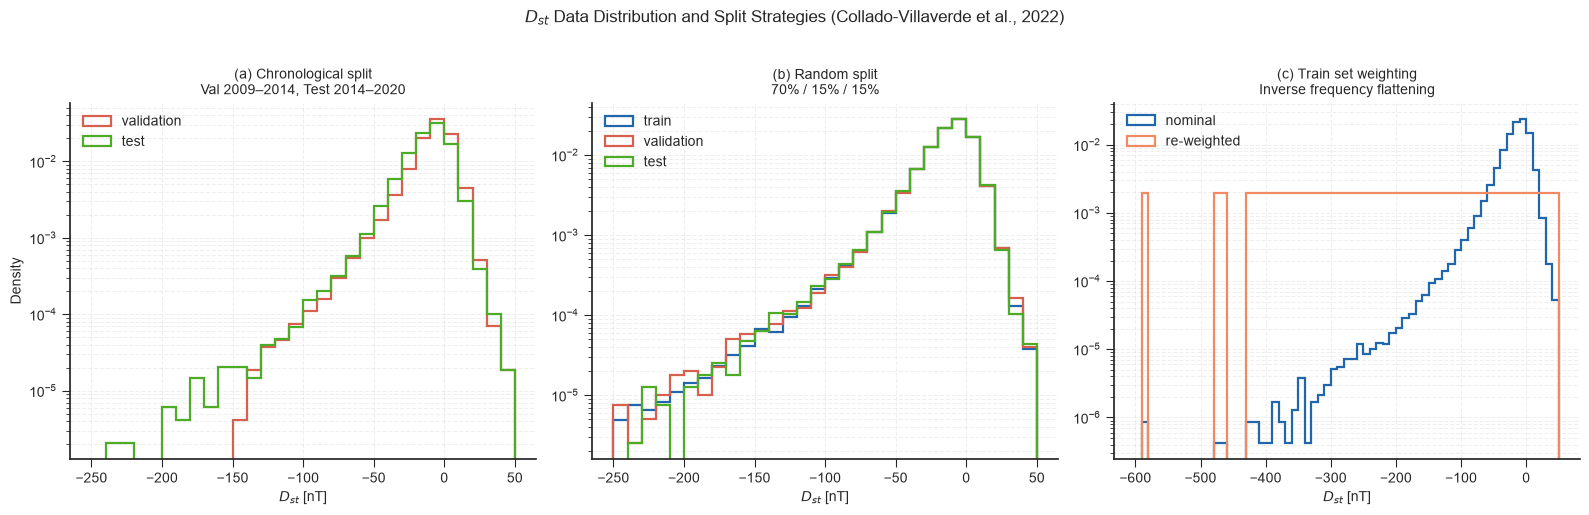

In [8]:

plot_dst_split_distribution(
    save_path='images/fig_dst_split_distribution.png'
)

Because geomagnetic storm occurrence varies across the solar cycle, a chronological split produces different Dst distributions in the training and evaluation periods. In particular, the storm tail is less represented in the validation and test segments than in the training data. This distributional mismatch is illustrated in Figure `Dst Data Distribution and Split Strategies (Collado-Villaverde et al., 2022)` and motivates the use of storm sample weighting during model training.

> **Observations — Distributional Properties of the Chronological Split:**
>
> * The chronological split creates a clear distributional mismatch in the storm tail. The training period (1995–2008) includes the active Solar Cycles 22–23, whereas `Val_Main` and `Test_Quiet` correspond largely to the weaker Solar Cycle 24. Consequently, extreme storms ($D_{st} < -100$ nT) are much less frequent in the evaluation segments.
> * `Val_Storm` has the highest storm fraction (13.1%), confirming that the Halloween and November 2003 events are successfully isolated for dedicated storm evaluation.
> * `Test_Quiet` has the lowest storm fraction (1.4%), providing a realistic assessment of model performance under relatively quiet space-weather conditions.
> * The 21-hour purge zones remove only a negligible number of observations while preventing information leakage across segment boundaries.
> * The distributional mismatch introduced by the chronological split motivates the storm-weighting strategy adopted later during model training.


Val_Storm is carved from the training period rather than appended after it, following the evaluation strategy of Nair et al. [NAI23]. This preserves an extreme storm interval for independent assessment while allowing the remaining training data to span the full Solar Cycle 23. The resulting non-contiguous training set (Train_1 and Train_2) is implemented as the union of two chronological intervals separated by a purge zone.

Hyperparameter optimisation uses Val_Main only. Val_Storm is reserved for post-selection storm diagnostics and is never used during parameter tuning. The two test segments (Test_Active and Test_Quiet) are evaluated only once, after all modelling decisions have been finalised [CAM19].

In [9]:
# ── Train / Validation / Test Split ──────────────────────────────────────
# Six chronological segments with 21-hour purge zones.
# Pre-1995 observations are excluded based on the survivability audit.
# Val_Storm is reserved for dedicated storm diagnostics.

PURGE_H = 21

BOUNDARIES = {
    'train1_start':       pd.Timestamp('1995-01-01 00:00'),
    'train1_end':         pd.Timestamp('2003-10-14 23:00'),
    'val_storm_start':    pd.Timestamp('2003-10-15 00:00'),
    'val_storm_end':      pd.Timestamp('2003-12-15 23:00'),
    'train2_start':       pd.Timestamp('2003-12-16 00:00'),
    'train2_end':         pd.Timestamp('2008-12-31 23:00'),
    'val_main_start':     pd.Timestamp('2009-01-01 00:00'),
    'val_main_end':       pd.Timestamp('2014-12-31 23:00'),
    'test_active_start':  pd.Timestamp('2015-01-01 00:00'),
    'test_active_end':    pd.Timestamp('2015-12-31 23:00'),
    'test_quiet_start':   pd.Timestamp('2016-01-01 00:00'),
    'test_quiet_end':     pd.Timestamp('2023-07-10 23:00'),
}

dt = feat['datetime']

def segment_mask(start_key, end_key, purge_start=True, purge_end=True):
    """Returns boolean mask for a segment, with optional purge zones."""
    start = BOUNDARIES[start_key]
    end   = BOUNDARIES[end_key]
    if purge_start:
        start = start + pd.Timedelta(hours=PURGE_H)
    if purge_end:
        end   = end   - pd.Timedelta(hours=PURGE_H)
    return (dt >= start) & (dt <= end)

masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

print(f"{'Segment':>12} {'Rows':>8} {'% total':>8} {'Storm hrs':>10} {'Storm %':>8}")
print("─" * 52)

assigned = pd.Series(False, index=feat.index)
total_storm = ((feat['dst_target_7h'] < -50) & feat['dst_target_7h'].notna()).sum()

for name, mask in masks.items():
    rows      = mask.sum()
    pct       = 100 * rows / len(feat)
    storm_hrs = ((feat.loc[mask, 'dst_target_7h'] < -50) &
                  feat.loc[mask, 'dst_target_7h'].notna()).sum()
    storm_pct = 100 * storm_hrs / rows if rows > 0 else 0
    print(f"{name:>12} {rows:>8,} {pct:>7.1f}% {storm_hrs:>10,} {storm_pct:>7.1f}%")
    assigned  = assigned | mask

print("─" * 52)
unassigned_mask  = ~assigned
rows_u    = unassigned_mask.sum()
pct_u     = 100 * rows_u / len(feat)
storm_u   = ((feat.loc[unassigned_mask, 'dst_target_7h'] < -50) &
              feat.loc[unassigned_mask, 'dst_target_7h'].notna()).sum()
storm_pct_u = 100 * storm_u / rows_u if rows_u > 0 else 0
print(f"{'unassigned':>12} {rows_u:>8,} {pct_u:>7.1f}% {storm_u:>10,} {storm_pct_u:>7.1f}%")
print("─" * 52)
print(f"{'total':>12} {len(feat):>8,} {'100.0%':>8} {total_storm:>10,}")

     Segment     Rows  % total  Storm hrs  Storm %
────────────────────────────────────────────────────
       train  121,185    33.2%      5,704     4.7%
   val_storm    1,446     0.4%        190    13.1%
    val_main   52,542    14.4%      1,165     2.2%
 test_active    8,718     2.4%        660     7.6%
  test_quiet   65,931    18.1%        932     1.4%
────────────────────────────────────────────────────
  unassigned  114,906    31.5%     10,892     9.5%
────────────────────────────────────────────────────
       total  364,728   100.0%     19,543


> **Observations — Segment Size and Storm Coverage:**
>
> * The five modelling segments contain 68.5% of the available observations (249,822 rows). The remaining 31.5% correspond primarily to the pre-1995 exclusion and the purge zones at segment boundaries.
> * The assigned segments contain 8,651 of the 19,543 storm hours (44.3%). Most excluded storm observations originate from the pre-1995 period and are treated as a study limitation.
> * `Val_Storm` has the highest storm fraction (13.1%), confirming that the Halloween and November 2003 events are successfully isolated for dedicated storm evaluation.
> * `Test_Quiet` has the lowest storm fraction (1.4%), providing an evaluation period dominated by relatively quiet geomagnetic conditions.
> * The 21-hour purge zones remove only a negligible number of observations while preventing leakage between adjacent segments.


### Missing Data Imputation

Missing values are imputed only after the train/validation/test split. All imputation parameters are estimated from the training data, ensuring that no information from the validation or test periods influences the preprocessing.

Two standard strategies were considered:

* **Forward fill (`ffill`)** preserves temporal continuity by propagating the most recent valid observation. This is appropriate for hourly solar wind measurements but becomes unreliable over long gaps.
* **Median imputation** is robust to outliers and avoids propagating stale values, but it ignores the temporal evolution of the solar wind.

The adopted approach combines both methods. Missing values are first forward-filled with a maximum gap of three hours. Any remaining missing values are then replaced using the median computed from the training set. The three-hour limit is consistent with the characteristic response time of the magnetosphere to changes in the interplanetary magnetic field `[BUR75]`.

Forward fill is applied independently within each dataset segment, ensuring that no values propagate across train, validation, or test boundaries.


In [10]:
# ── Imputation ────────────────────────────────────────────────────────────────
# Strategy: ffill (max 3h) within each segment, then median fill for remaining NaN.
# Medians fitted on train only — applied to all segments to prevent leakage.

# Ensure chronological order
feat = feat.sort_values('datetime').reset_index(drop=True)
dt   = feat['datetime']

# Recompute masks after sort
masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

# Compute medians on train only
train_medians = feat.loc[masks['train'], FEATURE_COLS].median()
n_nan_medians = train_medians.isna().sum()
print(f"NaN in train medians : {n_nan_medians}")
if n_nan_medians > 0:
    print(train_medians[train_medians.isna()])

def impute_segment(df, mask, medians, ffill_limit=3):
    """
    Impute NaN values in FEATURE_COLS within one segment only:
    1. Forward-fill up to ffill_limit consecutive hours.
    2. Fill remaining NaN values with training-set medians.

    The segment is copied before imputation, so forward-fill cannot cross
    train/validation/test boundaries.
    """
    seg = df.loc[mask, FEATURE_COLS].copy()
    seg = seg.ffill(limit=ffill_limit)
    seg = seg.fillna(medians)
    df.loc[mask, FEATURE_COLS] = seg

# Impute all segments
for name, mask in masks.items():
    impute_segment(feat, mask, train_medians, ffill_limit=3)

# Verify
print(f"\n{'Segment':>12} {'NaN remaining':>15}")
print("─" * 30)
for name, mask in masks.items():
    n_nan = feat.loc[mask, FEATURE_COLS].isna().sum().sum()
    print(f"{name:>12} {n_nan:>15,}")

NaN in train medians : 0

     Segment   NaN remaining
──────────────────────────────
       train               0
   val_storm               0
    val_main               0
 test_active               0
  test_quiet               0


> **Observations — Imputation:**
> - Training-set medians contain no missing values, so all 33 features have a valid fallback value.
> - After hybrid imputation (`ffill` up to 3 hours + training median fill), no missing values remain in any modelling segment.
> - Forward fill is applied independently within each segment, preventing values from propagating across train, validation, or test boundaries.
> - Median values are fitted on the training segment only and then applied to `val_storm`, `val_main`, `test_active`, and `test_quiet`, preventing distribution leakage from future periods.

### Saving Feature Engineering Artifacts

The outputs of the feature engineering stage are saved for reuse in the subsequent notebooks. Persisting these artifacts avoids repeating preprocessing and guarantees that feature selection, hyperparameter optimisation, and model evaluation all use an identical experimental setup.

Three artifacts are exported:

- **Split masks (`masks`)** — Boolean index arrays defining the training, validation, and test segments.
- **Imputed feature matrix (`feat_split.parquet`)** — the complete feature matrix after feature engineering and imputation. The data remain **unscaled**; any model-specific scaling is performed later.
- **Project constants (`context_constants.pkl`)** — shared configuration values used throughout the project:
  - `FEATURE_COLS` — names of the 33 predictor variables;
  - `K_HORIZONS` — forecast horizons (1, 3, 7, 12, and 21 hours);
  - `STORM_THR` — Dst threshold defining storm conditions;
  - `PURGE_H` — purge width (21 hours) used at segment boundaries;
  - `BOUNDARIES` — timestamps defining the train, validation, and test intervals.

In [11]:
# ── Save Feature Engineering Artifacts ───────────────────────────────────
# Persist the outputs of Feature Engineering for downstream notebooks.

# 1. Split masks — boolean masks for each segment
joblib.dump(masks, 'models/split_masks.pkl')
print("Saved: models/split_masks.pkl")

# 2. Imputed feature matrix (unscaled)
feat.to_parquet('data/processed/feat_split.parquet')
print(f"Saved: data/processed/feat_split.parquet  ({len(feat):,} rows, {feat.shape[1]} columns)")

# 3. Constants from this notebook
joblib.dump({
    'FEATURE_COLS' : FEATURE_COLS,
    'K_HORIZONS'   : K_HORIZONS,
    'STORM_THR'    : STORM_THR,
    'PURGE_H'      : PURGE_H,
    'BOUNDARIES'   : BOUNDARIES,
}, 'models/context_constants.pkl')
print("Saved: models/context_constants.pkl")

Saved: models/split_masks.pkl
Saved: data/processed/feat_split.parquet  (364,728 rows, 72 columns)
Saved: models/context_constants.pkl
